In [1]:
!pip install -q nltk scikit-learn


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
df = pd.read_csv('Reviews.csv')  # replace with your uploaded file name

# Drop rows with missing values in 'text' or 'score'
df = df[['Score', 'Text']].dropna()

# Filter only positive and negative reviews
df = df[df['Score'] != 3]  # remove neutral
df['sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)
df = df[['Text', 'sentiment']]
df.rename(columns={'Text': 'review'}, inplace=True)

df.head()


ParserError: Error tokenizing data. C error: EOF inside string starting at row 92411

In [4]:
df = pd.read_csv('Reviews.csv')  # replace with your uploaded file name

# Drop rows with missing values in 'text' or 'score'
df = df[['Score', 'Text']].dropna()

# Filter only positive and negative reviews
df = df[df['Score'] != 3]  # remove neutral
df['sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)
df = df[['Text', 'sentiment']]
df.rename(columns={'Text': 'review'}, inplace=True)

df.head()


,review,sentiment
0,I have bought several of the Vitality canned d...,1
1,Product arrived labeled as Jumbo Salted Peanut...,0
2,This is a confection that has been around a fe...,1
3,If you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wid...,1


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(clean_text)


In [6]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

params = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'tfidf__min_df': [1, 2],
    'clf__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, param_grid=params, cv=3, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10],
                         'tfidf__max_df': [0.8, 0.9, 1.0],
                         'tfidf__min_df': [1, 2],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             verbose=1)

Best Parameters: {'clf__C': 10, 'tfidf__max_df': 0.8, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Accuracy: 0.9403667687935704
              precision    recall  f1-score   support

           0       0.88      0.72      0.80      3600
           1       0.95      0.98      0.97     18921

    accuracy                           0.94     22521
   macro avg       0.92      0.85      0.88     22521
weighted avg       0.94      0.94      0.94     22521



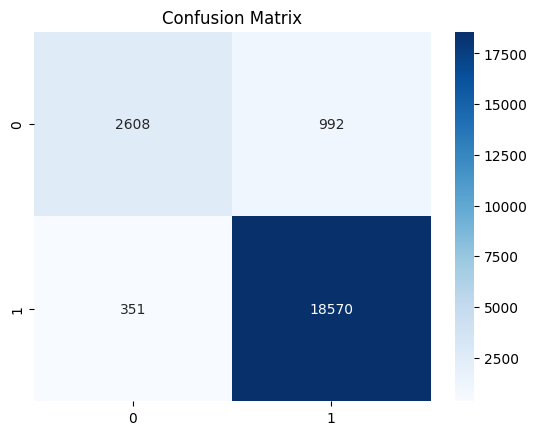

In [8]:
y_pred = grid.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [9]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    return "Positive" if grid.predict([cleaned])[0] == 1 else "Negative"

predict_sentiment("The product is really awesome and works great.")


'Positive'